In [3]:
import pandas as pd
#Loading data
df = pd.read_csv('Titanic-Dataset.csv')

## Exploration
Loading and exploring the Titanic dataset to understand its structure, 
shape, and data types before cleaning.

In [4]:
#exploration
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
print(f"Shape: {df.shape}")

Shape: (891, 12)


In [6]:
print(f"Column names: {df.columns}")

Column names: Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [7]:
print(f"Column datatypes:\n{df.dtypes}")

Column datatypes:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [8]:
print(f"Summary stats:\n{df.describe()}")

Summary stats:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


In [9]:
print(f"Null values in entire dataset: {df.isnull().sum().sum()}")

Null values in entire dataset: 866


In [10]:
print(f"Null values per column:\n{df.isnull().sum()}")

Null values per column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [11]:
print(f"Uniqur value in sex column: {df['Sex'].unique()}\nUnique values in Embarkes column: {df['Embarked'].unique()}")

Uniqur value in sex column: ['male' 'female']
Unique values in Embarkes column: ['S' 'C' 'Q' nan]


## Filtering and selecting

In [12]:
df[['Name','Age','Survived']]

,Name,Age,Survived
0,"Braund, Mr. Owen Harris",22.0,0
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1
2,"Heikkinen, Miss. Laina",26.0,1
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1
4,"Allen, Mr. William Henry",35.0,0
...,...,...,...
886,"Montvila, Rev. Juozas",27.0,0
887,"Graham, Miss. Margaret Edith",19.0,1
888,"Johnston, Miss. Catherine Helen ""Carrie""",NaN,0
889,"Behr, Mr. Karl Howell",26.0,1


In [13]:
#passengers who survived
df[df['Survived']==1][['Name', 'Survived']]

,Name,Survived
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1
2,"Heikkinen, Miss. Laina",1
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1
8,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",1
9,"Nasser, Mrs. Nicholas (Adele Achem)",1
...,...,...
875,"Najib, Miss. Adele Kiamie ""Jane""",1
879,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",1
880,"Shelley, Mrs. William (Imanita Parrish Hall)",1
887,"Graham, Miss. Margaret Edith",1


In [14]:
#female passengers over 30
df[(df['Sex'] == 'female') & (df['Age'] > 30)][['Name','Age','Sex']]

,Name,Age,Sex
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,female
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,female
11,"Bonnell, Miss. Elizabeth",58.0,female
15,"Hewlett, Mrs. (Mary D Kingcome)",55.0,female
18,"Vander Planke, Mrs. Julius (Emelia Maria Vande...",31.0,female
...,...,...,...
862,"Swift, Mrs. Frederick Joel (Margaret Welles Ba...",48.0,female
865,"Bystrom, Mrs. (Karolina)",42.0,female
871,"Beckwith, Mrs. Richard Leonard (Sallie Monypeny)",47.0,female
879,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",56.0,female


In [15]:
#passengers of pclass 1 or 2
df[df['Pclass'].isin([1,2])][['Name','Pclass']]

,Name,Pclass
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1
6,"McCarthy, Mr. Timothy J",1
9,"Nasser, Mrs. Nicholas (Adele Achem)",2
11,"Bonnell, Miss. Elizabeth",1
...,...,...
880,"Shelley, Mrs. William (Imanita Parrish Hall)",2
883,"Banfield, Mr. Frederick James",2
886,"Montvila, Rev. Juozas",2
887,"Graham, Miss. Margaret Edith",1


In [16]:
#passengers where age is not null
df[df['Age'].notna()][['Name','Age']]

,Name,Age
0,"Braund, Mr. Owen Harris",22.0
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0
2,"Heikkinen, Miss. Laina",26.0
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0
4,"Allen, Mr. William Henry",35.0
...,...,...
885,"Rice, Mrs. William (Margaret Norton)",39.0
886,"Montvila, Rev. Juozas",27.0
887,"Graham, Miss. Margaret Edith",19.0
889,"Behr, Mr. Karl Howell",26.0


In [17]:
#first 5 rows anmd 3 cols 
df.iloc[0:5,0:3]

,PassengerId,Survived,Pclass
0,1,0,3
1,2,1,1
2,3,1,3
3,4,1,1
4,5,0,3


## Data Cleaning
Handling missing values in Age (filled with median) and Embarked 
(filled with mode). Dropping Cabin due to 77% missing values.

In [18]:
#filling missing age with median
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Age'].isna().sum()

np.int64(0)

In [19]:
#filling embarked with mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Embarked'].isna().sum()

np.int64(0)

In [20]:
#dropped col
df = df.drop(columns='Cabin')
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')

In [21]:
#checking for nulls
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [22]:
df.drop_duplicates()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


In [23]:
#encoding
df['Sex'] = df['Sex'].map({'male': 0, 'female':1})
df['Sex'].unique()

array([0, 1])

In [24]:
#confirming datatypes 
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex              int64
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Embarked        object
dtype: object

In [25]:
#fixing dtypes
df['Age'] = df['Age'].astype(int)

In [26]:
df['Embarked'].unique()

array(['S', 'C', 'Q'], dtype=object)

In [27]:
df['Embarked'] = df['Embarked'].map({'S': 0,'C': 1,'Q': 2})
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex              int64
Age              int64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Embarked         int64
dtype: object

In [28]:
#leaving name and ticket as it is for now may drop them later on 

## Feature Engineering
Creating new features: FamilySize, IsAlone, AgeGroup, Title, FarePerPerson.
These give the ML model more signal than raw columns alone.

In [29]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df[['FamilySize', 'SibSp', 'Parch']]

,FamilySize,SibSp,Parch
0,2,1,0
1,2,1,0
2,1,0,0
3,2,1,0
4,1,0,0
...,...,...,...
886,1,0,0
887,1,0,0
888,4,1,2
889,1,0,0


In [30]:
def func(size):
    if size == 1:
        return 1
    else:
        return 0
df['IsAlone'] = df['FamilySize'].apply(func)
df[['IsAlone','FamilySize']]

,IsAlone,FamilySize
0,0,2
1,0,2
2,1,1
3,0,2
4,1,1
...,...,...
886,1,1
887,1,1
888,0,4
889,1,1


In [31]:
df['AgeGroup'] = df['Age'].apply(lambda x: 'child' if x  < 18  else 'adult' if x < 60 else 'senior')
df[['Age','AgeGroup']]

,Age,AgeGroup
0,22,adult
1,38,adult
2,26,adult
3,35,adult
4,35,adult
...,...,...
886,27,adult
887,19,adult
888,28,adult
889,26,adult


In [32]:
df['FarePerPerson'] = df['Fare']/df['FamilySize']
df[['Fare','FarePerPerson','FamilySize']]

,Fare,FarePerPerson,FamilySize
0,7.2500,3.62500,2
1,71.2833,35.64165,2
2,7.9250,7.92500,1
3,53.1000,26.55000,2
4,8.0500,8.05000,1
...,...,...,...
886,13.0000,13.00000,1
887,30.0000,30.00000,1
888,23.4500,5.86250,4
889,30.0000,30.00000,1


In [33]:
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
df[['Name','Title']]

,Name,Title
0,"Braund, Mr. Owen Harris",Mr
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs
2,"Heikkinen, Miss. Laina",Miss
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs
4,"Allen, Mr. William Henry",Mr
...,...,...
886,"Montvila, Rev. Juozas",Rev
887,"Graham, Miss. Margaret Edith",Miss
888,"Johnston, Miss. Catherine Helen ""Carrie""",Miss
889,"Behr, Mr. Karl Howell",Mr


## aggregation

In [34]:
#survival rate by sex
rate = df.groupby('Sex')['Survived'].mean()
if rate[0] > rate[1]:
    print(f'Survival rate of men was greater')
elif rate[1] > rate[0]:
    print(f'Survival rate of women was greater')
else:
    print(f'Survival rate was equal')
    

Survival rate of women was greater


In [35]:
#survival rate by p class
df.groupby('Pclass')['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [36]:
#avg age by pclass
df.groupby('Pclass')['Age'].mean()


Pclass
1    36.805556
2    29.744565
3    25.914460
Name: Age, dtype: float64

In [37]:
df.groupby(['Pclass','Sex'])['Age'].mean()


Pclass  Sex
1       0      38.983607
        1      33.978723
2       0      30.481481
        1      28.697368
3       0      26.893372
        1      23.555556
Name: Age, dtype: float64

In [38]:
df.groupby('AgeGroup').size()

AgeGroup
adult     752
child     113
senior     26
dtype: int64

In [39]:
df.groupby('Pclass')['Fare'].mean()


Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64

In [40]:
df.groupby('IsAlone')['Survived'].mean()

IsAlone
0    0.505650
1    0.303538
Name: Survived, dtype: float64

## sorting and final analysis

In [41]:

df.sort_values(by = 'Age', ascending = False)['Age']

630    80
851    74
96     71
493    71
672    70
       ..
78      0
469     0
644     0
831     0
755     0
Name: Age, Length: 891, dtype: int64

In [42]:
sorted_fare = df.sort_values(by = 'Fare', ascending = False)
sorted_fare.iloc[0]

PassengerId                   259
Survived                        1
Pclass                          1
Name             Ward, Miss. Anna
Sex                             1
Age                            35
SibSp                           0
Parch                           0
Ticket                   PC 17755
Fare                     512.3292
Embarked                        1
FamilySize                      1
IsAlone                         1
AgeGroup                    adult
FarePerPerson            512.3292
Title                        Miss
Name: 258, dtype: object

In [43]:
sorted_fare.head()['Ticket']

258    PC 17755
737    PC 17755
679    PC 17755
88        19950
27        19950
Name: Ticket, dtype: object

In [44]:
df[(df['Title'] == 'Mr') & (df['Survived']==0)]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,IsAlone,AgeGroup,FarePerPerson,Title
0,1,0,3,"Braund, Mr. Owen Harris",0,22,1,0,A/5 21171,7.2500,0,2,0,adult,3.6250,Mr
4,5,0,3,"Allen, Mr. William Henry",0,35,0,0,373450,8.0500,0,1,1,adult,8.0500,Mr
5,6,0,3,"Moran, Mr. James",0,28,0,0,330877,8.4583,2,1,1,adult,8.4583,Mr
6,7,0,1,"McCarthy, Mr. Timothy J",0,54,0,0,17463,51.8625,0,1,1,adult,51.8625,Mr
12,13,0,3,"Saundercock, Mr. William Henry",0,20,0,0,A/5. 2151,8.0500,0,1,1,adult,8.0500,Mr
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
878,879,0,3,"Laleff, Mr. Kristo",0,28,0,0,349217,7.8958,0,1,1,adult,7.8958,Mr
881,882,0,3,"Markun, Mr. Johann",0,33,0,0,349257,7.8958,0,1,1,adult,7.8958,Mr
883,884,0,2,"Banfield, Mr. Frederick James",0,28,0,0,C.A./SOTON 34068,10.5000,0,1,1,adult,10.5000,Mr
884,885,0,3,"Sutehall, Mr. Henry Jr",0,25,0,0,SOTON/OQ 392076,7.0500,0,1,1,adult,7.0500,Mr


In [45]:
survived_child = len(df[(df['AgeGroup']=='child')&(df['Survived']==1)])
total_child =  len(df[(df['AgeGroup']=='child')])
perc = (survived_child/total_child)*100
print(f"{perc}")

53.98230088495575


## Visualisation 

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

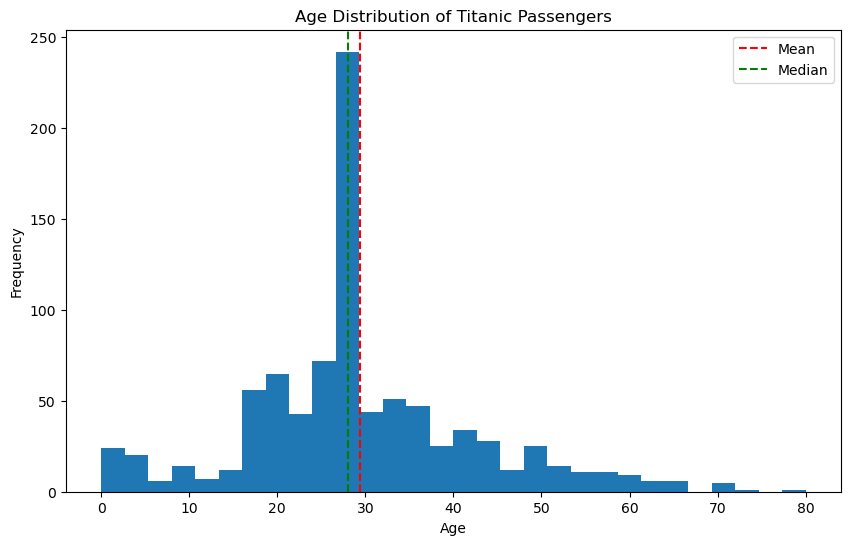

In [47]:
plt.figure(figsize = (10,6))
plt.hist(df['Age'], bins = 30)
plt.title('Age Distribution of Titanic Passengers')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.axvline(df['Age'].mean(), color = 'red', linestyle ='--',label='Mean')
plt.axvline(df['Age'].median(), color = 'green', linestyle ='--',label='Median')
plt.legend()
plt.show()


The average age of passengers in titanic was 30 years

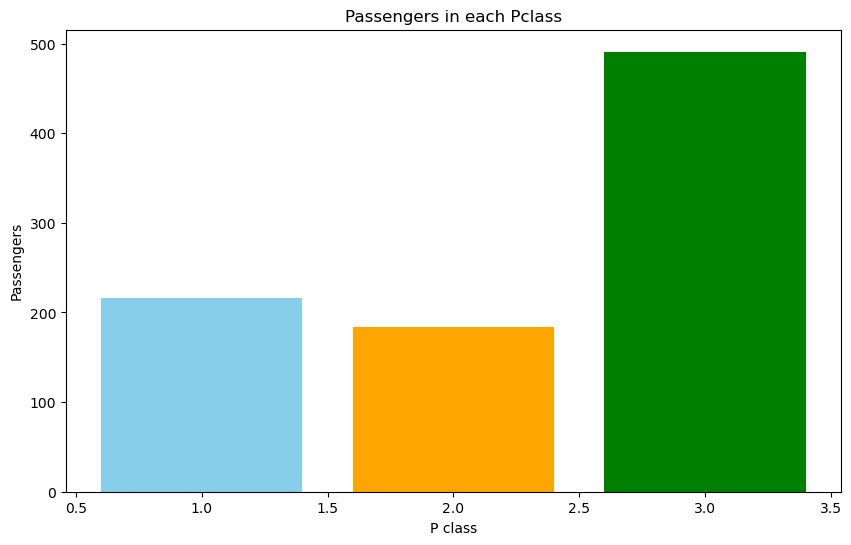

In [48]:
pclass_counts = df['Pclass'].value_counts().sort_index()
plt.figure(figsize=(10, 6))
bars = plt.bar(
    pclass_counts.index,
    pclass_counts.values,
    color=['skyblue', 'orange', 'green']
)
plt.title('Passengers in each Pclass')
plt.xlabel("P class")
plt.ylabel("Passengers")
plt.show()

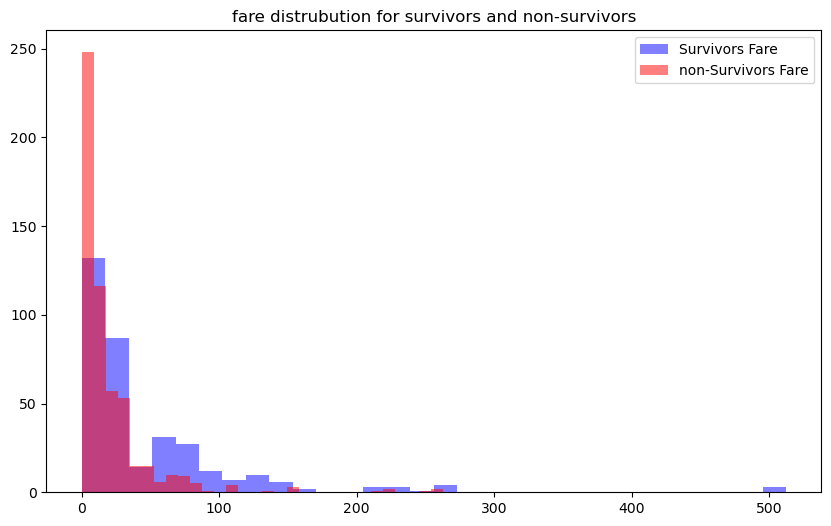

In [49]:
plt.figure(figsize= (10, 6))
fare_survivors = df[df['Survived'] == 1]['Fare']
fare_nonsurvivors = df[df['Survived'] == 0]['Fare']

plt.hist(fare_survivors, bins = 30, alpha = 0.5, label= 'Survivors Fare', color='blue')
plt.hist(fare_nonsurvivors, bins = 30, alpha = 0.5, label= 'non-Survivors Fare', color='red')
plt.legend()
plt.title('fare distrubution for survivors and non-survivors')
plt.show()


People who did not survive paid more fare generally

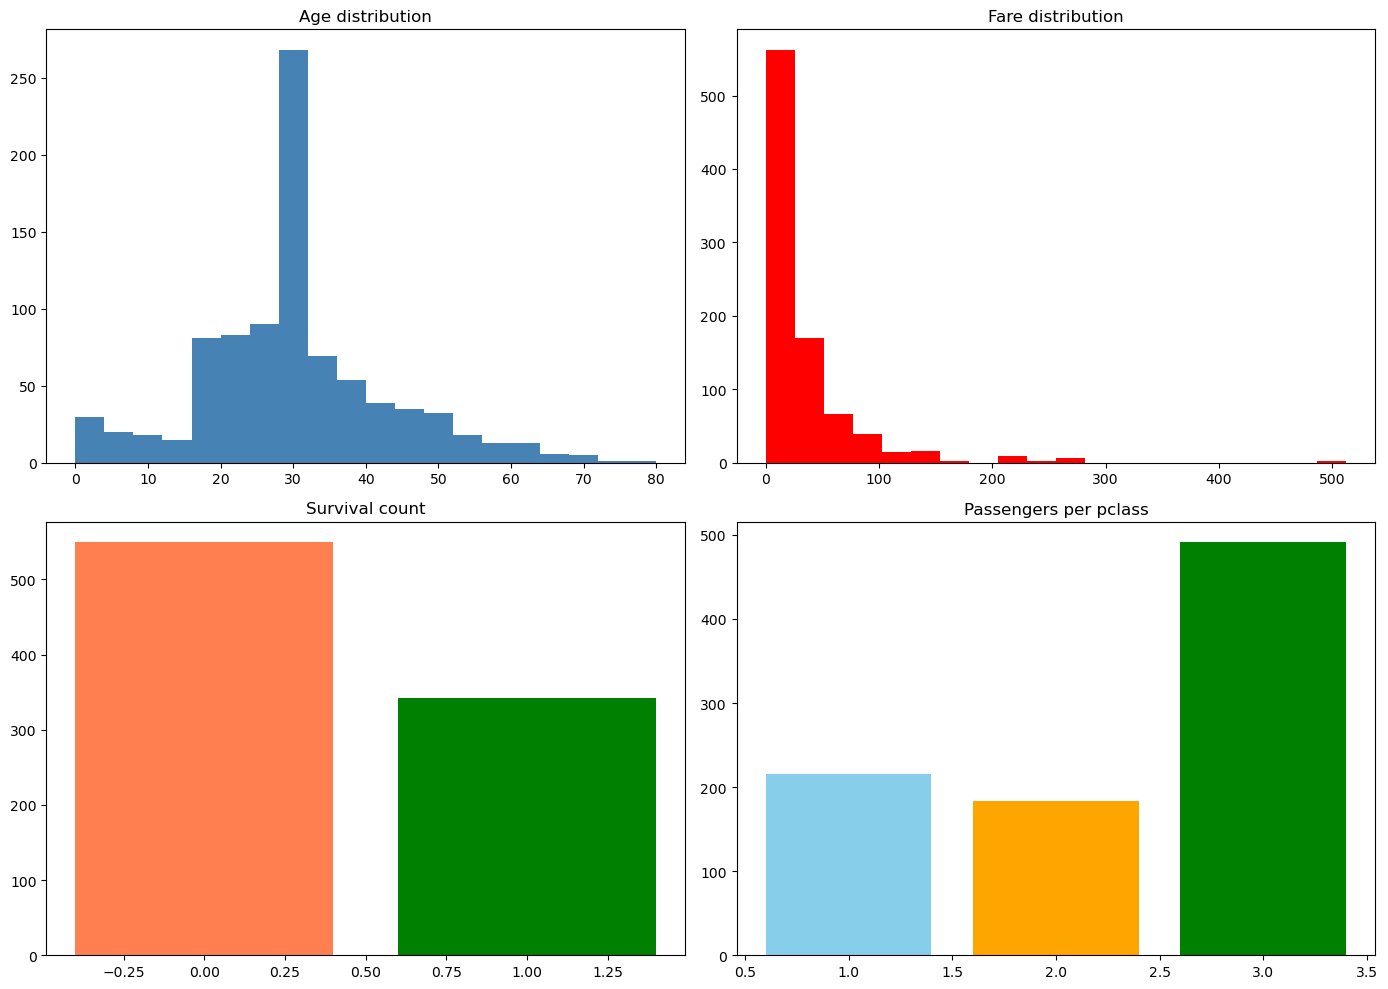

In [50]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))
axes[0,0].hist(df['Age'], bins = 20, color='steelblue')
axes[0,0].set_title('Age distribution')
axes[0,1].hist(df['Fare'], bins = 20, color='red')
axes[0,1].set_title('Fare distribution')
count = df['Survived'].value_counts()

axes[1,0].bar(count.index, count.values, color=['coral', 'green'])
axes[1,0].set_title('Survival count')
pclass_counts = df['Pclass'].value_counts().sort_index()
axes[1,1].bar(
    pclass_counts.index,
    pclass_counts.values,
    color=['skyblue', 'orange', 'green']
)
axes[1,1].set_title('Passengers per pclass')
plt.tight_layout()
plt.show()

AgeGroup
0-10     0.543860
10-20    0.379310
20-30    0.333333
30-40    0.445161
40-50    0.392857
50-60    0.404762
60-70    0.222222
70-80    0.250000
Name: Survived, dtype: float64


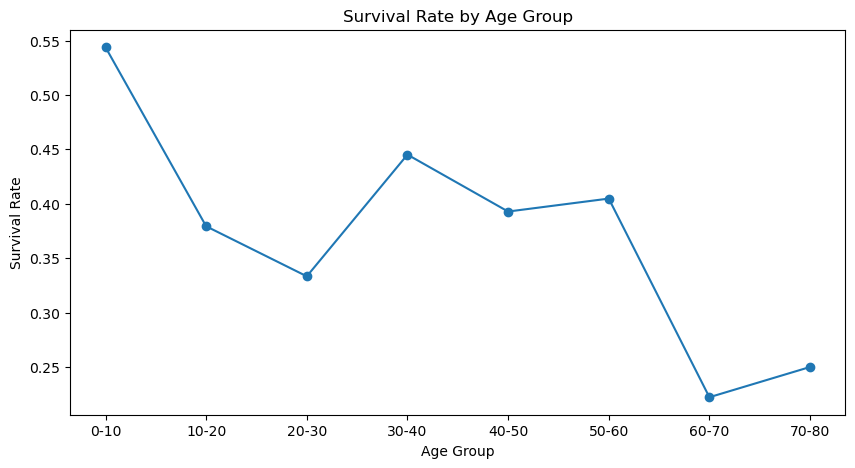

In [51]:
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80]
labels = ['0-10', '10-20', '20-30', '30-40', '40-50', 
          '50-60', '60-70', '70-80']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)
age_survival = df.groupby('AgeGroup', observed=True)['Survived'].mean()
print(age_survival)
plt.figure(figsize=(10,5))
plt.plot(
    age_survival.index,
    age_survival.values,
    marker='o',
    linestyle='-'
)

plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate")


plt.show()

#Statistical Analysis

In [54]:
print('Age -- Mean: ', df['Age'].mean())
print('Age -- Median: ', df['Age'].median())

print('Age -- Mode: ', df['Age'].mode()[0])

print('Fare -- Mean: ', df['Fare'].mean())

print('Fare -- Median: ', df['Fare'].median())



Age -- Mean:  29.34567901234568
Age -- Median:  28.0
Age -- Mode:  28
Fare -- Mean:  32.204207968574636
Fare -- Median:  14.4542


In [55]:
print('Age skewness: ', df['Age'].skew())
print('Fare skewness: ', df['Fare'].skew())


Age skewness:  0.5035697085944845
Fare skewness:  4.787316519674893


In [57]:
print('Age standard deviation: ', df['Age'].std())
print('Age variance: ', df['Age'].var())
print('Fare standard deviation: ', df['Fare'].std())
print('Fare variance: ', df['Fare'].var())

Age standard deviation:  13.028211862792078
Age variance:  169.73430434179625
Fare standard deviation:  49.693428597180905
Fare variance:  2469.436845743117


In [59]:
df[["Age", "Fare", "SibSp", "Parch"]].describe() 

,Age,Fare,SibSp,Parch
count,891.000000,891.000000,891.000000,891.000000
mean,29.345679,32.204208,0.523008,0.381594
std,13.028212,49.693429,1.102743,0.806057
min,0.000000,0.000000,0.000000,0.000000
25%,22.000000,7.910400,0.000000,0.000000
50%,28.000000,14.454200,0.000000,0.000000
75%,35.000000,31.000000,1.000000,0.000000
max,80.000000,512.329200,8.000000,6.000000


Age: IQR=13.0
Fare: IQR=23.0896


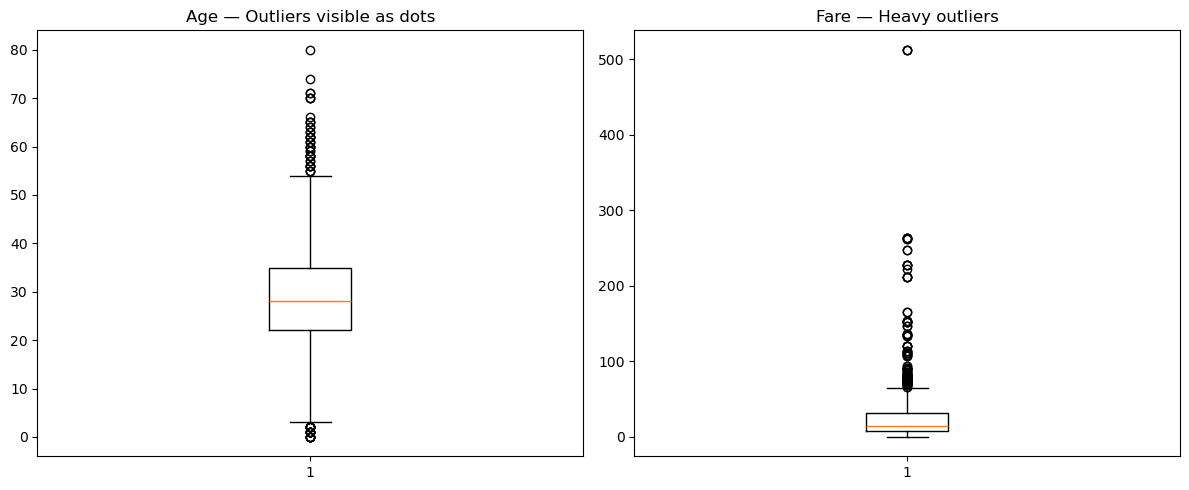

In [61]:
def outliers(col):
    q1=df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    upper= q3 + 1.5*iqr
    lower = q1 - 1.5*iqr
    outliers= df[(df[col]<lower) | (df[col]>upper)]
    print(f'{col}: IQR={iqr}')
    return outliers
age = outliers('Age')
fare = outliers('Fare')
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].boxplot(df["Age"].dropna())
axes[0].set_title("Age — Outliers visible as dots")
axes[1].boxplot(df["Fare"])
axes[1].set_title("Fare — Heavy outliers")
plt.tight_layout()
plt.show()

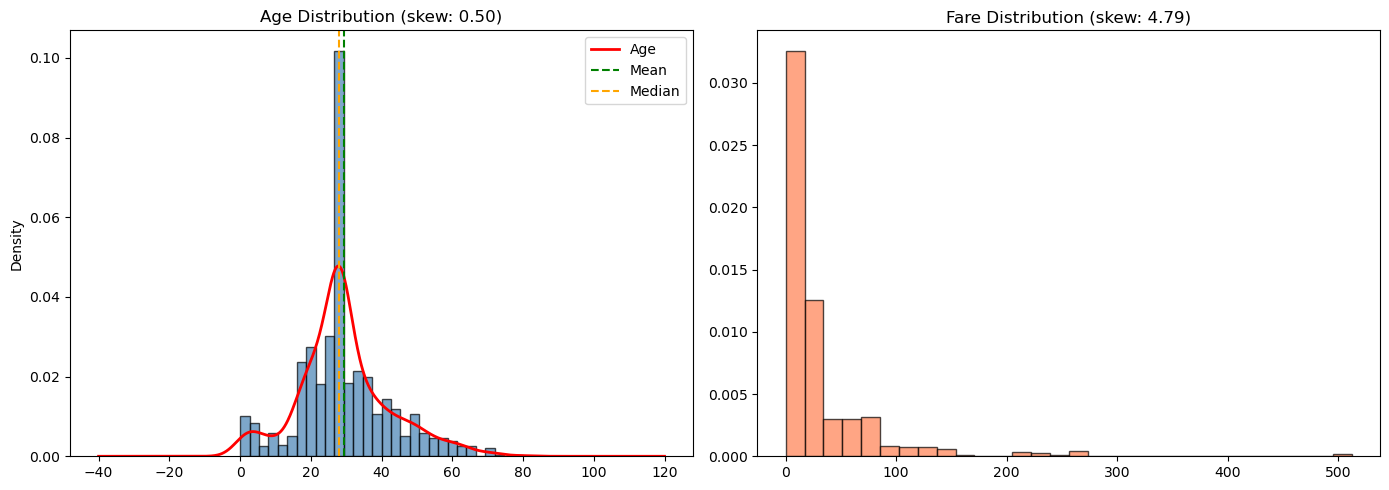

Passengers with Age Z-score > 2 (unusually old):
    Age  Age_zscore
11   58    2.199406
33   66    2.813458
54   65    2.736701
94   59    2.276162
96   71    3.197240


In [63]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["Age"].dropna(), bins=30, edgecolor="black",
             color="steelblue", alpha=0.7, density=True)
df["Age"].dropna().plot.kde(ax=axes[0], color="red", linewidth=2)
axes[0].axvline(df["Age"].mean(), color="green",
                linestyle="--", label="Mean")
axes[0].axvline(df["Age"].median(), color="orange",
                linestyle="--", label="Median")
axes[0].set_title(f"Age Distribution (skew: {df['Age'].skew():.2f})")
axes[0].legend()
axes[1].hist(df["Fare"], bins=30, edgecolor="black",
             color="coral", alpha=0.7, density=True)
axes[1].set_title(f"Fare Distribution (skew: {df['Fare'].skew():.2f})")
plt.tight_layout()
plt.show()
df["Age_zscore"] = (df["Age"] - df["Age"].mean()) / df["Age"].std()
print("Passengers with Age Z-score > 2 (unusually old):")
print(df[df["Age_zscore"] > 2][["Age", "Age_zscore"]].head())

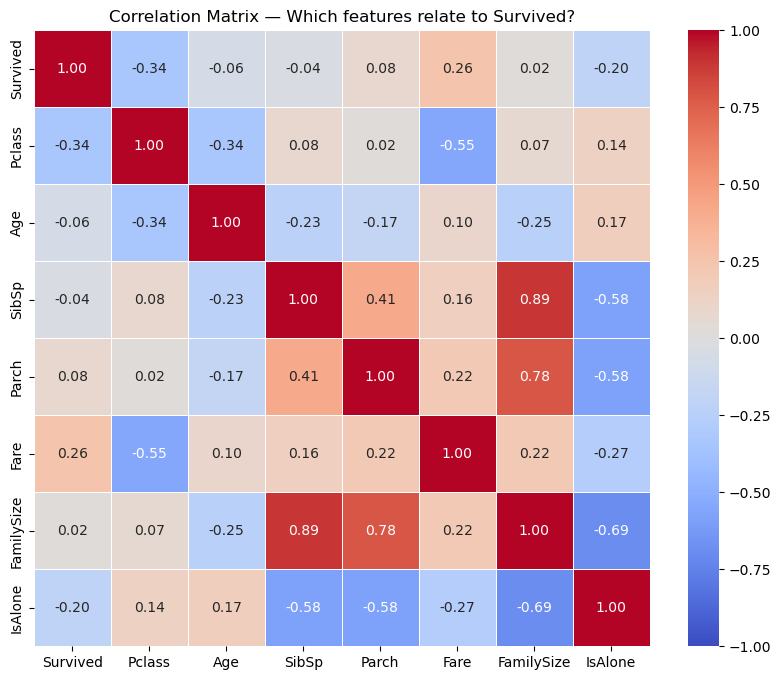

Correlation with Survived (sorted):
Survived      1.000000
Fare          0.257307
Parch         0.081629
FamilySize    0.016639
SibSp        -0.035322
Age          -0.064909
IsAlone      -0.203367
Pclass       -0.338481
Name: Survived, dtype: float64

Pclass vs Fare correlation: -0.549
Negative means: higher class number = lower fare (makes sense)

SibSp vs FamilySize: 0.891


In [64]:
corr = df[["Survived", "Pclass", "Age", "SibSp",
           "Parch", "Fare", "FamilySize", "IsAlone"]].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title("Correlation Matrix — Which features relate to Survived?")
plt.show()
print("Correlation with Survived (sorted):")
print(corr["Survived"].sort_values(ascending=False))
print(f"\nPclass vs Fare correlation: {df['Pclass'].corr(df['Fare']):.3f}")
print("Negative means: higher class number = lower fare (makes sense)")
print(f"\nSibSp vs FamilySize: {df['SibSp'].corr(df['FamilySize']):.3f}")

In [66]:
# Q1: What was the overall survival rate?
survival_rate = df["Survived"].mean() * 100
print(f"Overall survival rate: {survival_rate:.1f}%")

# Q2: Did gender determine survival?
print("\nSurvival rate by gender:")
print(df.groupby("Sex")["Survived"].mean() * 100)

# Q3: Did class determine survival?
print("\nSurvival rate by Pclass:")
print(df.groupby("Pclass")["Survived"].mean() * 100)

# Q4: Did age matter?
survivors = df[df["Survived"] == 1]["Age"].dropna()
non_survivors = df[df["Survived"] == 0]["Age"].dropna()
print(f"\nAverage age of survivors: {survivors.mean():.1f}")
print(f"Average age of non-survivors: {non_survivors.mean():.1f}")

# Q5: Did family size matter?
print("\nSurvival rate by FamilySize:")
print(df.groupby("FamilySize")["Survived"].mean() * 100)

# Q6: Did being alone hurt survival?
print("\nSurvival rate by IsAlone:")
print(df.groupby("IsAlone")["Survived"].mean() * 100)

# Q7: Which title survived most?
print("\nSurvival rate by Title:")
print(df.groupby("Title")["Survived"].mean().sort_values(ascending=False) * 100)

Overall survival rate: 38.4%

Survival rate by gender:
Sex
0    18.890815
1    74.203822
Name: Survived, dtype: float64

Survival rate by Pclass:
Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

Average age of survivors: 28.3
Average age of non-survivors: 30.0

Survival rate by FamilySize:
FamilySize
1     30.353818
2     55.279503
3     57.843137
4     72.413793
5     20.000000
6     13.636364
7     33.333333
8      0.000000
11     0.000000
Name: Survived, dtype: float64

Survival rate by IsAlone:
IsAlone
0    50.564972
1    30.353818
Name: Survived, dtype: float64

Survival rate by Title:
Title
Sir         100.000000
Countess    100.000000
Ms          100.000000
Mme         100.000000
Lady        100.000000
Mlle        100.000000
Mrs          79.200000
Miss         69.780220
Master       57.500000
Col          50.000000
Major        50.000000
Dr           42.857143
Mr           15.667311
Jonkheer      0.000000
Don           0.000000
Rev           0.

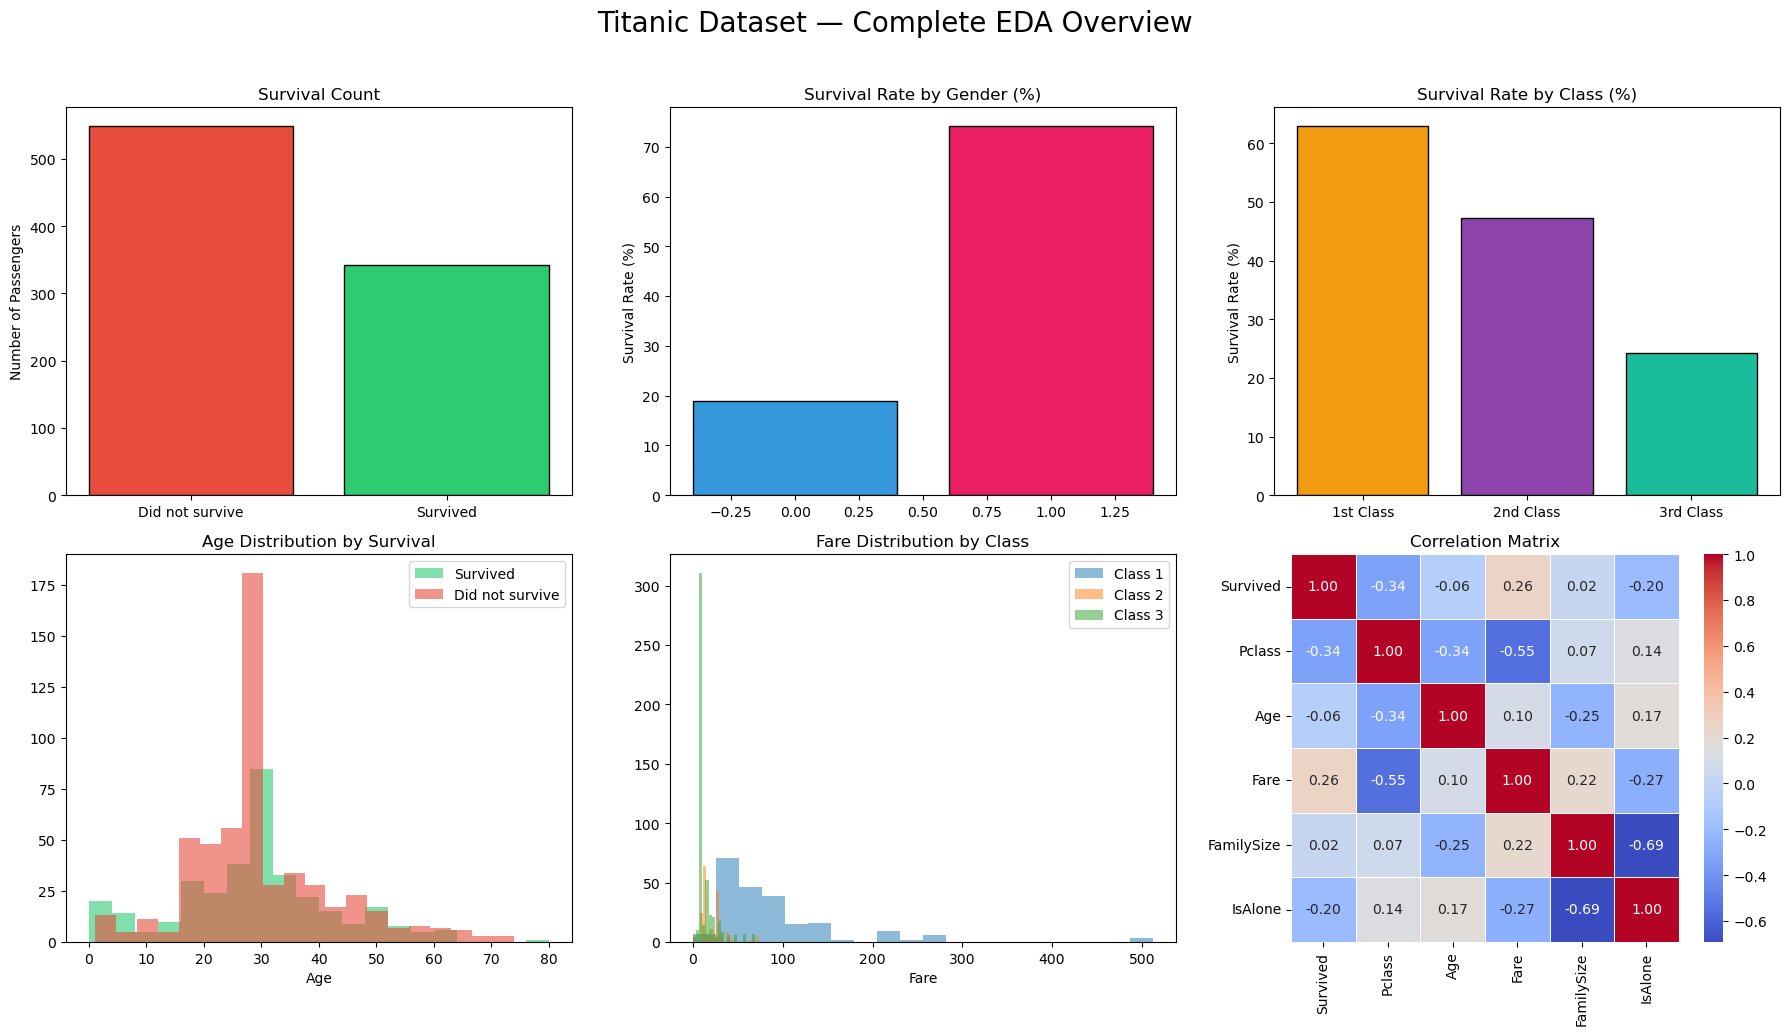

Chart saved as titanic_overview.png


In [67]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Overall survival
survival_counts = df["Survived"].value_counts()
axes[0,0].bar(["Did not survive", "Survived"],
              survival_counts.values,
              color=["#E74C3C", "#2ECC71"], edgecolor="black")
axes[0,0].set_title("Survival Count")
axes[0,0].set_ylabel("Number of Passengers")

# 2. Survival by gender
gender_survival = df.groupby("Sex")["Survived"].mean() * 100
axes[0,1].bar(gender_survival.index, gender_survival.values,
              color=["#3498DB", "#E91E63"], edgecolor="black")
axes[0,1].set_title("Survival Rate by Gender (%)")
axes[0,1].set_ylabel("Survival Rate (%)")

# 3. Survival by class
class_survival = df.groupby("Pclass")["Survived"].mean() * 100
axes[0,2].bar(["1st Class", "2nd Class", "3rd Class"],
              class_survival.values,
              color=["#F39C12", "#8E44AD", "#1ABC9C"], edgecolor="black")
axes[0,2].set_title("Survival Rate by Class (%)")
axes[0,2].set_ylabel("Survival Rate (%)")

# 4. Age distribution by survival
axes[1,0].hist(df[df["Survived"]==1]["Age"].dropna(),
               bins=20, alpha=0.6, label="Survived", color="#2ECC71")
axes[1,0].hist(df[df["Survived"]==0]["Age"].dropna(),
               bins=20, alpha=0.6, label="Did not survive", color="#E74C3C")
axes[1,0].set_title("Age Distribution by Survival")
axes[1,0].set_xlabel("Age")
axes[1,0].legend()

# 5. Fare distribution by class
for pclass in [1, 2, 3]:
    axes[1,1].hist(df[df["Pclass"]==pclass]["Fare"],
                   bins=20, alpha=0.5, label=f"Class {pclass}")
axes[1,1].set_title("Fare Distribution by Class")
axes[1,1].set_xlabel("Fare")
axes[1,1].legend()

# 6. Correlation heatmap
corr = df[["Survived","Pclass","Age","Fare","FamilySize","IsAlone"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            ax=axes[1,2], square=True, linewidths=0.5)
axes[1,2].set_title("Correlation Matrix")

plt.suptitle("Titanic Dataset — Complete EDA Overview", fontsize=20, y=1.02)
plt.tight_layout()
plt.savefig("titanic_overview.png", dpi=300, bbox_inches="tight",
            facecolor="white")
plt.show()
print("Chart saved as titanic_overview.png")